In [1]:
%matplotlib widget

In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import empymod 
from scipy.constants import mu_0
import pygimli as pg
from pygimli.viewer.mpl import drawModel1D
from sklearn.metrics import root_mean_squared_error
from numpy import linalg as LA
from itertools import product
import plotly.express as px
import pandas as pd
from mpl_toolkits.mplot3d import axes3d
import matplotlib.colors as colors
import random

# Find Ill-posedness of an inversion problem

In [3]:
# Create a large range of models

# Define EC of first layer in mS/m
sigma_1 = np.logspace(2,3, 1000)

# EC of second layer with constant ratios
sigma_2 = sigma_1 / 10

# Define a constant product of sigma_1 * thick_1
product_s1t1 = 500

# Define thickness of first layer in meters
thick_1 = product_s1t1 / sigma_1

# Create the models array (EC in S/m)

models =list(np.array([ thick_1, sigma_1/1000, sigma_2/1000]).T)

start_models = list(np.array([ thick_1, sigma_1/1000, sigma_2/1000]).T)  #list(np.array([np.ones_like(sigma_sm), sigma_sm/1000, sigma_sm/1000]).T)


# Forward Function

In [4]:
def FDEM(sigmas, thicks, coil_orient=np.array(['H', 'P', 'V']), height=0.15):

    Freq = 9000
    coil_spacing = [2, 4, 8]
    coil_spacing_p = [2.1, 4.1, 8.2]
    
    res_air = 1e6 # air resistivity
    
    sigmas = np.array(sigmas)
    res = np.hstack(([res_air], 1/sigmas))
    
   # print('res: ', res)
    
    depth = np.hstack(([0],-np.cumsum(thicks)))
    
   # print('depth:', depth)
    
    # Define source and receivers geometry
    
    source = [0, 0, -height]
    receivers = [coil_spacing, np.zeros_like(coil_spacing), -height]
    receivers_p = [coil_spacing_p, np.zeros_like(coil_spacing_p), -height]
    
    # Define resistivity model
    #res = np.hstack((res_air, res)) # include air resistivity
    
    # Empty array to store store responses
    OUT = []
    
    # Calculate for horizontal coil orientation
    if any(coil_orient == 'H'):
        # Secondary magnetic field
        H_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        # Primary magnetic field
        H_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                              ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp() * 1e3 # Out of Phase
        ip = (H_Hs/H_Hp).real.amp() * 1e3 # In Phase
        OUT.append([op, ip])

    # Calculate for vertical coil orientation
    if any(coil_orient == 'V'):
        # Secondary magnetic field
        V_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 55, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        # Primary magnetic field
        V_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq, ab = 55, 
                              verb=0)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp() * 1e3 # Out of Phase
        ip = (V_Hs/V_Hp).real.amp() * 1e3 # In Phase
        OUT.append([op, ip])

    # Calculate for perpendicular coil orientation
    if any(coil_orient == 'P'):
        P_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 46, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        P_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime= Freq,
                              ab = 66, verb = 0)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp() * 1e3 # Out of Phase
        ip = (P_Hs/P_Hp).real.amp() * 1e3 # In Phase

        OUT.append([op, ip])

    return np.array(OUT).ravel()

# Forward modelling class

In [5]:
class FDEM_1D(pg.frameworks.Modelling):
    """ Class to Initialize the model for Gauss-Newton inversion
    using the quadrature (Q) and in-phase (IP) components of the measurements
    for a n-layered model
    
    Input:

        nlay : number of layers
    """   
    def __init__(self, nlay=3):
        self.nlay = nlay
        mesh = pg.meshtools.createMesh1DBlock(nlay)
        super().__init__()
        self.setMesh(mesh)

    def response(self, par):
        """ Compute response vector for a certain model [mod] 
        par = [thickness_1, thickness_2, ..., thickness_n, sigma_1, sigma_2, ..., sigma_n]
        """
      #  print('model:', par)  
        resp = FDEM(sigmas = par[self.nlay-1:],
                           thicks = par[:self.nlay-1]
                              )
        return resp
    
    def response_mt(self, par, i=0):
        """Multi-threaded forward response."""
        return self.response(par)
        
    def drawModel(self, ax, model):
        pg.viewer.mpl.drawModel1D(ax = ax,
                                  model = model,
                                  plot = 'semilogx',
                                  xlabel = 'Electrical conductivity (S/m)',
                                  )
        ax.set_ylabel('Depth in (m)')

# Define random starting models

In [6]:
random.seed(10)
model_start_1 = random.sample(start_models, k=1)[0]
model_start_1

array([1.29832799, 0.3851107 , 0.03851107])

In [7]:
model_true_1 = random.sample(models, k=1)[0]
model_true_1

array([4.63379665, 0.10790288, 0.01079029])

# Run Inversion

In [8]:
# Inversion for 2 Layers

FOP = FDEM_1D(nlay = 2)

data = FOP.response(model_true_1)
data *=  1 + 0.025 *np.random.rand(len(data))

transThk = pg.trans.TransLogLU(0.01,5.1)
transSig = pg.trans.TransLogLU(1/1000,2000/1000)

FOP.region(0).setTransModel(transThk)
FOP.region(1).setTransModel(transSig)

inv = pg.Inversion()
inv.setForwardOperator(FOP)
J = inv.fop.jacobian()

rel_err = np.ones_like(data)*1e-1
model_inv = inv.run(data, rel_err, verbose=False, startModel=model_start_1, lam=0, )

model_inv

3 [3.507377465934169, 0.10984196743168367, 0.03807041447537451]

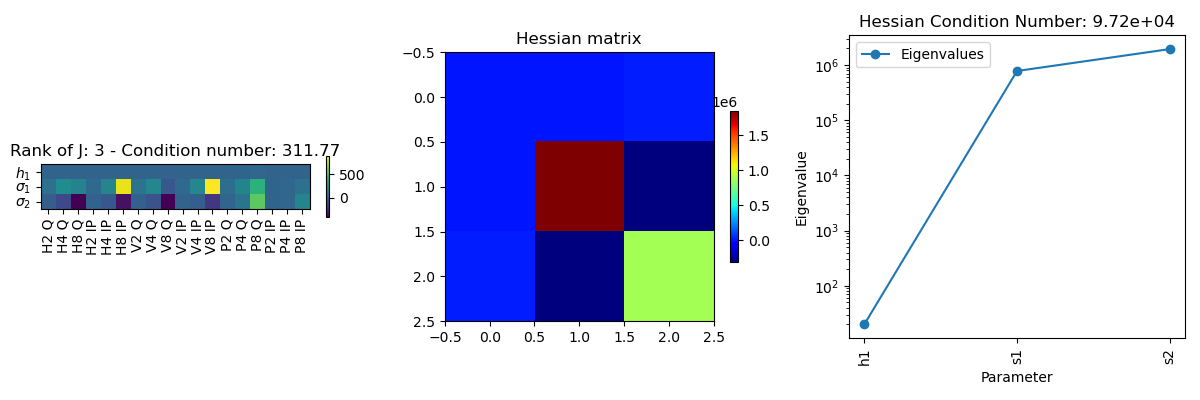

In [9]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

# Plot Jacobian
c = ax[0].imshow(np.array(J).T)
fig.colorbar(c, shrink=0.2, ax=ax[0])
xticks = ['H2 Q', 'H4 Q', 'H8 Q', 'H2 IP', 'H4 IP', 'H8 IP', 'V2 Q', 'V4 Q', 'V8 Q',
          'V2 IP', 'V4 IP', 'V8 IP', 'P2 Q', 'P4 Q', 'P8 Q', 'P2 IP', 'P4 IP', 'P8 IP' ]
yticks = ['$h_1$', '$\sigma_1$', '$\sigma_2$' ]
ax[0].set_xticks(range(len(data)), labels=xticks, rotation = 90)
ax[0].set_yticks(range(len(model_true_1)), labels=yticks)
ax[0].set_title('Rank of J: ' + str( np.linalg.matrix_rank(J)) +' - Condition number: %.2f' %np.linalg.cond(J) )

# Calculate Hessian
J = np.array(J)
JTJ = np.matmul(J.T,J)
# Plot Hessian
c = ax[1].imshow(JTJ, cmap='jet') 
fig.colorbar(c, ax=ax[1], shrink=0.5)
ax[1].set_title('Hessian matrix')

# Compute eigenvalues
eigenvalues, eigenvectors = LA.eigh(JTJ)  # More stable for symmetric matrices

# Plot eigenvalues

xticks = ['h1', 's1', 's2']

ax[2].set_xticks(range(3), labels=xticks, rotation = 90)
ax[2].semilogy(eigenvalues, 'o-', label="Eigenvalues")
#ax[2].axhline(y=0, color='r', linestyle='--', label="Zero Line")
ax[2].set_xlabel("Parameter")
ax[2].set_ylabel("Eigenvalue")
ax[2].legend()

# Print condition number
condition_number = np.max(eigenvalues) / np.min(eigenvalues)
ax[2].set_title(f"Hessian Condition Number: {condition_number:.2e}")

plt.tight_layout()

# Check with 10 different starting models

In [10]:
random.seed(10)
model_start_10 = random.sample(start_models, k=10)
model_start_10

[array([1.29832799, 0.3851107 , 0.03851107]),
 array([4.63379665, 0.10790288, 0.01079029]),
 array([1.81773498, 0.2750676 , 0.02750676]),
 array([1.60131035, 0.31224428, 0.03122443]),
 array([1.28049655, 0.39047352, 0.03904735]),
 array([4.8300874 , 0.1035178 , 0.01035178]),
 array([3.07438883, 0.16263395, 0.0162634 ]),
 array([1.6807245 , 0.29749075, 0.02974908]),
 array([0.7347459 , 0.68050737, 0.06805074]),
 array([1.56843491, 0.31878913, 0.03187891])]

In [11]:
# Run inversions

J_s = []

for sm in model_start_10:
    # Inversion for 2 Layers

    FOP = FDEM_1D(nlay = 2)
    
    data = FOP.response(model_true_1)
    data *=  1 + 0.025 *np.random.rand(len(data))
    
    transThk = pg.trans.TransLogLU(0.01,5.1)
    transSig = pg.trans.TransLogLU(1/1000,2000/1000)
    
    FOP.region(0).setTransModel(transThk)
    FOP.region(1).setTransModel(transSig)
    
    inv = pg.Inversion()
    inv.setForwardOperator(FOP)
    J = inv.fop.jacobian()
    
    rel_err = np.ones_like(data)*1e-1
    model_inv = inv.run(data, rel_err, verbose=False, startModel=sm, lam=0, )
    J_s.append(np.array(J))

In [12]:
# Calculate rank, Condition number, hessians and eigenvalues

rank_J = []
CN_J = []
CN_H = []
eigenvalues_H = []
#ev_h1 = []
#ev_s1 = []
#ev_s2 = []
condition = []

for j in J_s:
    rank_J.append(np.linalg.matrix_rank(j))
    CN_J.append(np.linalg.cond(j))
    H = np.matmul(j.T, j)
    eigenvalues, eigenvectors = LA.eigh(H)
    eigenvalues_H.append(eigenvalues)
    CN_H.append( np.max(eigenvalues) / np.min(eigenvalues))
    
    if np.all(np.array(eigenvalues) > 0):
        condition.append(1)
        print("The Hessian is positive definite → Likely a global minimum.")
    elif np.any(np.array(eigenvalues) < 0):
        condition.append(-1)
        print("The Hessian has negative eigenvalues → Could be a saddle point or local maximum.")
    else:
        condition.append(0)
        print("The Hessian has near-zero eigenvalues → Possible flat directions (ill-conditioning).")


The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.
The Hessian is positive definite → Likely a global minimum.


In [13]:
df_10 = pd.DataFrame(data= np.array([np.array(model_start_10)[:,0], np.array(model_start_10)[:,1], np.array(model_start_10)[:,2], rank_J,
                                 CN_J, CN_H, condition]).T, columns = ['h_1', 'sig_1', 'sig_2', 'rank_J', 'CN_J', 'CN_H', 'cond'])


In [14]:
df_10.style.highlight_max(subset=pd.IndexSlice[:, ['cond']], color='green')

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond
0,1.298328,0.385111,0.038511,3.000000,299.681721,89809.133739,1.000000
1,4.633797,0.107903,0.010790,3.000000,833.683954,695028.935341,1.000000
2,1.817735,0.275068,0.027507,3.000000,280.523381,78693.367265,1.000000
3,1.601310,0.312244,0.031224,3.000000,566.778588,321237.968327,1.000000
4,1.280497,0.390474,0.039047,3.000000,1090.567458,1189337.380453,1.000000
5,4.830087,0.103518,0.010352,3.000000,933.070257,870620.104114,1.000000
6,3.074389,0.162634,0.016263,3.000000,218.350285,47676.847169,1.000000
7,1.680725,0.297491,0.029749,3.000000,595.658007,354808.461475,1.000000
8,0.734746,0.680507,0.068051,3.000000,895.853388,802553.293293,1.000000
9,1.568435,0.318789,0.031879,3.000000,575.851073,331604.458186,1.000000


# Check with 100 different starting models

In [15]:
random.seed(10)
model_start_100 = random.sample(start_models, k=100)

# Run inversions

J_s = []
model_test = []

for sm in model_start_100:
    # Inversion for 2 Layers
    if (sm == model_true_1).any():
        pass
    else:
        model_test.append(sm)
        FOP = FDEM_1D(nlay = 2)
        
        data = FOP.response(model_true_1)
        data *=  1 + 0.025 *np.random.rand(len(data))
        
        transThk = pg.trans.TransLogLU(0.01,5.1)
        transSig = pg.trans.TransLogLU(1/1000,2000/1000)
        
        FOP.region(0).setTransModel(transThk)
        FOP.region(1).setTransModel(transSig)
        
        inv = pg.Inversion()
        inv.setForwardOperator(FOP)
        J = inv.fop.jacobian()
        
        rel_err = np.ones_like(data)*1e-1
        model_inv = inv.run(data, rel_err, verbose=False, startModel=sm, lam=0, )
        J_s.append(np.array(J))

# Calculate rank, Condition number, hessians and eigenvalues

rank_J = []
CN_J = []
CN_H = []
eigenvalues_H = []
#ev_h1 = []
#ev_s1 = []
#ev_s2 = []
condition = []

for j in J_s:
    rank_J.append(np.linalg.matrix_rank(j))
    CN_J.append(np.linalg.cond(j))
    H = np.matmul(j.T, j)
    eigenvalues, eigenvectors = LA.eigh(H)
    eigenvalues_H.append(eigenvalues)
    CN_H.append( np.max(eigenvalues) / np.min(eigenvalues))
    
    if np.all(np.array(eigenvalues) > 0):
        condition.append(1)
       # print("The Hessian is positive definite → Likely a global minimum.")
    elif np.any(np.array(eigenvalues) < 0):
        condition.append(-1)
       # print("The Hessian has negative eigenvalues → Could be a saddle point or local maximum.")
    else:
        condition.append(0)
       # print("The Hessian has near-zero eigenvalues → Possible flat directions (ill-conditioning).")


In [16]:
df_100 = pd.DataFrame(data= np.array([np.array(model_test)[:,0], np.array(model_test)[:,1], np.array(model_test)[:,2], rank_J,
                                 CN_J, CN_H, condition]).T, columns = ['h_1', 'sig_1', 'sig_2', 'rank_J', 'CN_J', 'CN_H', 'cond'])

df_100.style.background_gradient(subset=pd.IndexSlice[:, ['rank_J', 'CN_J', 'CN_H','cond']])

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond
0,1.298328,0.385111,0.038511,3.000000,292.331620,85457.775797,1.000000
1,1.817735,0.275068,0.027507,3.000000,686.051668,470666.890668,1.000000
2,1.601310,0.312244,0.031224,3.000000,713.187289,508636.109791,1.000000
3,1.280497,0.390474,0.039047,3.000000,1020.130277,1040665.782635,1.000000
4,4.830087,0.103518,0.010352,3.000000,933.070257,870620.104114,1.000000
5,3.074389,0.162634,0.016263,3.000000,218.350285,47676.847169,1.000000
6,1.680725,0.297491,0.029749,3.000000,666.684831,444468.664336,1.000000
7,0.734746,0.680507,0.068051,3.000000,892.901427,797272.959176,1.000000
8,1.568435,0.318789,0.031879,3.000000,665.546744,442952.467878,1.000000
9,0.716351,0.697981,0.069798,3.000000,823.715612,678507.409293,1.000000


In [17]:
df_100[df_100['cond']==0].style.highlight_min(subset=pd.IndexSlice[:, ['cond']], color='red')

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond


# Check with 1000 starting models

In [22]:
# Run inversions

J_s = []
models_test = []

for sm in start_models:
    # Inversion for 2 Layers
    if (sm == model_true_1).any():
        pass
    else:
        models_test.append(sm)
        FOP = FDEM_1D(nlay = 2)
        
        data = FOP.response(model_true_1)
        data *=  1 + 0.025 *np.random.rand(len(data))
        
        transThk = pg.trans.TransLogLU(0.01,5.1)
        transSig = pg.trans.TransLogLU(1/1000,2000/1000)
        
        FOP.region(0).setTransModel(transThk)
        FOP.region(1).setTransModel(transSig)
        
        inv = pg.Inversion()
        inv.setForwardOperator(FOP)
        J = inv.fop.jacobian()
        
        rel_err = np.ones_like(data)*1e-1
        model_inv = inv.run(data, rel_err, verbose=False, startModel=sm, lam=0, )
        J_s.append(np.array(J))

# Calculate rank, Condition number, hessians and eigenvalues

rank_J = []
CN_J = []
CN_H = []
eigenvalues_H = []
#ev_h1 = []
#ev_s1 = []
#ev_s2 = []
condition = []

for j in J_s:
    rank_J.append(np.linalg.matrix_rank(j))
    CN_J.append(np.linalg.cond(j))
    H = np.matmul(j.T, j)
    eigenvalues, eigenvectors = LA.eigh(H)
    eigenvalues_H.append(eigenvalues)
    CN_H.append( np.max(eigenvalues) / np.min(eigenvalues))
    
    if np.all(np.array(eigenvalues) > 0):
        condition.append(1)
       # print("The Hessian is positive definite → Likely a global minimum.")
    elif np.any(np.array(eigenvalues) < 0):
        condition.append(-1)
       # print("The Hessian has negative eigenvalues → Could be a saddle point or local maximum.")
    else:
        condition.append(0)
       # print("The Hessian has near-zero eigenvalues → Possible flat directions (ill-conditioning).")


In [23]:
df_1000 = pd.DataFrame(data= np.array([np.array(models_test)[:,0], np.array(models_test)[:,1], np.array(models_test)[:,2], rank_J,
                                 CN_J, CN_H, condition]).T, columns = ['h_1', 'sig_1', 'sig_2', 'rank_J', 'CN_J', 'CN_H', 'cond'])

df_1000.style.background_gradient(subset=pd.IndexSlice[:, ['rank_J', 'CN_J', 'CN_H','cond']])

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond
0,5.000000,0.100000,0.010000,3.000000,1017.485943,1035277.645104,1.000000
1,4.988489,0.100231,0.010023,3.000000,1011.837907,1023815.950612,1.000000
2,4.977004,0.100462,0.010046,3.000000,1006.191497,1012421.329582,1.000000
3,4.965546,0.100694,0.010069,3.000000,1000.546990,1001094.279468,1.000000
4,4.954114,0.100926,0.010093,3.000000,994.904668,989835.298552,1.000000
5,4.942709,0.101159,0.010116,3.000000,989.264821,978644.885200,1.000000
6,4.931329,0.101393,0.010139,3.000000,983.627743,967523.536995,1.000000
7,4.919976,0.101627,0.010163,3.000000,977.993737,956471.750062,1.000000
8,4.908649,0.101861,0.010186,3.000000,972.363110,945490.018232,1.000000
9,4.897348,0.102096,0.010210,3.000000,966.736175,934578.832369,1.000000


In [24]:
df_1000[df_1000['cond']==0].style.highlight_min(subset=pd.IndexSlice[:, ['cond']], color='red')

,h_1,sig_1,sig_2,rank_J,CN_J,CN_H,cond


Text(0.5, 0.98, 'Noise 2.5 %')

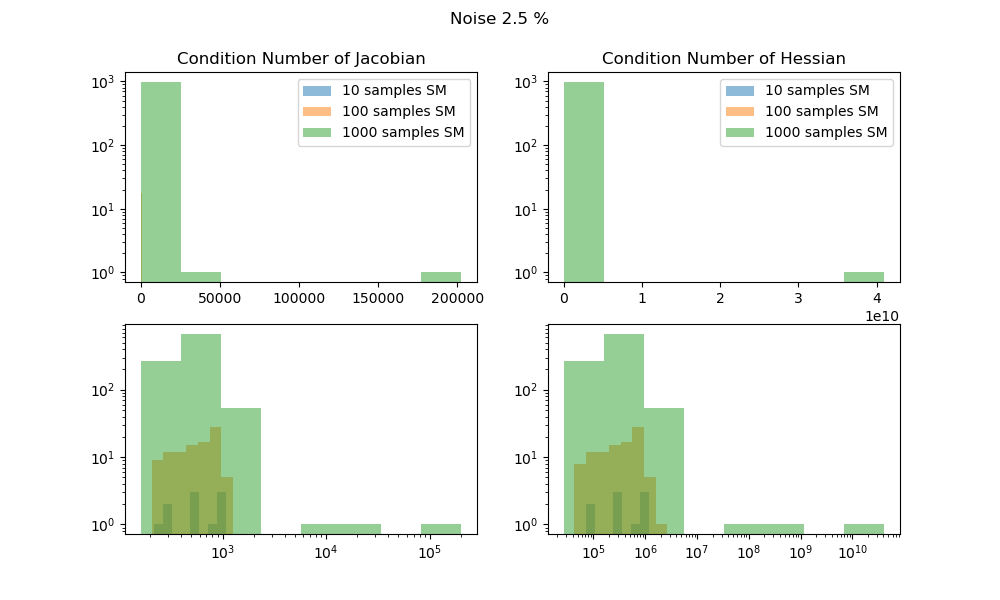

In [25]:
fig, ax = plt.subplots(2,2, figsize=(10,6))

hist, bins, _ = ax[0,0].hist(df_10['CN_J'], bins=8, alpha=0.5, label = '10 samples SM')
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,0].hist(df_10['CN_J'], alpha=0.5, bins=logbins, label = '10 samples SM')

hist, bins, _ = ax[0,0].hist(df_100['CN_J'], bins=8, alpha=0.5, label = '100 samples SM')
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,0].hist(df_100['CN_J'], alpha=0.5, bins=logbins, label = '100 samples SM')

hist, bins, _ = ax[0,0].hist(df_1000['CN_J'], bins=8, alpha=0.5, label = '1000 samples SM', log=True)
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,0].hist(df_1000['CN_J'], alpha=0.5, bins=logbins, label = '1000 samples SM', log=True)

ax[0,0].legend()
ax[1,0].set_xscale('log')
ax[0,0].set_title('Condition Number of Jacobian')

hist, bins, _ = ax[0,1].hist(df_10['CN_H'], bins=8, alpha=0.5, label = '10 samples SM')
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,1].hist(df_10['CN_H'], alpha=0.5, bins=logbins, label = '10 samples SM')

hist, bins, _ = ax[0,1].hist(df_100['CN_H'], bins=8, alpha=0.5, label = '100 samples SM')
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,1].hist(df_100['CN_H'], alpha=0.5, bins=logbins, label = '100 samples SM')

hist, bins, _ = ax[0,1].hist(df_1000['CN_H'], bins=8, alpha=0.5, label = '1000 samples SM', log=True)
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
ax[1,1].hist(df_1000['CN_H'], alpha=0.5, bins=logbins, label = '1000 samples SM', log=True)

ax[0,1].legend()
ax[1,1].set_xscale('log')
ax[0,1].set_title('Condition Number of Hessian')
fig.suptitle('Noise 2.5 %')